# Vancouver AI Job Market Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## 2. Load Data

In [2]:
DATA_DIR = Path(r"C:\Users\jerem\job_analysis\data")

In [3]:
list(DATA_DIR.glob("*.csv"))

[]

In [4]:
ml_df = pd.read_csv(
    DATA_DIR / "JobMarketVancouver" / "machine_learning.csv"
)

ai_df = pd.read_csv(
    DATA_DIR / "JobMarketVancouver" / "ai_engineer.csv"
)

de_df = pd.read_csv(
    DATA_DIR / "JobMarketVancouver" / "data_engineer.csv"
)

ds_df = pd.read_csv(
    DATA_DIR / "JobMarketVancouver" / "data_scientist.csv"
)

In [5]:
ml_df["category"] = "Machine Learning"
ai_df["category"] = "AI Engineer"
de_df["category"] = "Data Engineer"
ds_df["category"] = "Data Scientist"

In [6]:
df = pd.concat(
    [ml_df, ai_df, de_df, ds_df],
    ignore_index=True
)

## 3. Initial Exploration

In [7]:
df.shape

(200, 15)

In [8]:
df.head()

,Position,Title,Logo,Post Link,Company,Company Profile,Location,Actively Status,Description,Seniority level,Employment type,Job function,Industries,Time ago,category
0,1,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/C560BAQGE...,https://ca.linkedin.com/jobs/view/machine-lear...,Sanctuary AI,https://ca.linkedin.com/company/sanctuaryai?tr...,"Vancouver, British Columbia, Canada",NaN,"Your New Role and Team\n\nSanctuary AI, a worl...",Mid-Senior level,Full-time,Engineering and Information Technology,Software Development,2 months ago,Machine Learning
1,2,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/D560BAQGm...,https://ca.linkedin.com/jobs/view/machine-lear...,SAP,https://de.linkedin.com/company/sap?trk=public...,"Vancouver, British Columbia, Canada",NaN,"We help the world run better\n\nAt SAP, we kee...",Not Applicable,Full-time,Engineering and Information Technology,"Software Development, IT Services and IT Consu...",2 days ago,Machine Learning
2,3,Machine Learning Engineer - Sports Technology,https://media.licdn.com/dms/image/v2/D560BAQFF...,https://ca.linkedin.com/jobs/view/machine-lear...,EA SPORTS,https://ca.linkedin.com/company/easports?trk=p...,"Vancouver, British Columbia, Canada",NaN,Description & Requirements\n\nElectronic Arts ...,Not Applicable,Full-time,Engineering and Information Technology,Computer Games,2 weeks ago,Machine Learning
3,4,ML Engineer - Creator Studio,https://media.licdn.com/dms/image/v2/C560BAQHd...,https://ca.linkedin.com/jobs/view/ml-engineer-...,Apple,https://www.linkedin.com/company/apple?trk=pub...,"Vancouver, British Columbia, Canada",NaN,Summary\nApple is where individual imagination...,Not Applicable,Full-time,Engineering and Information Technology,Computers and Electronics Manufacturing,4 weeks ago,Machine Learning
4,5,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/C4E0BAQFQ...,https://ca.linkedin.com/jobs/view/machine-lear...,MobSquad,https://ca.linkedin.com/company/mobsquad?trk=p...,"Vancouver, British Columbia, Canada",NaN,"ABOUT MOBSQUAD\n\nWe are a well-funded, hyper-...",Mid-Senior level,Full-time,Engineering and Information Technology,IT Services and IT Consulting,1 year ago,Machine Learning


In [9]:
df.columns

Index(['Position', 'Title', 'Logo', 'Post Link', 'Company', 'Company Profile',
       'Location', 'Actively Status', 'Description', 'Seniority level',
       'Employment type', 'Job function', 'Industries', 'Time ago',
       'category'],
      dtype='str')

In [10]:
compteur = df["Title"].value_counts()
titre = df["Title"]

In [11]:
for t, c in zip(titre, compteur):
    print(t, c)

Machine Learning Engineer 14
Machine Learning Engineer 4
Machine Learning Engineer - Sports Technology 4
ML Engineer - Creator Studio 4
Machine Learning Engineer 4
Machine Learning Engineer - Document Intelligence 4
Intermediate Machine Learning Developer 3
AI/ML Engineer (USA & Canada) 3
Machine Learning Engineer 3
Applied AI/ML Scientist 3
Machine Learning Engineer - BC 3
AI/Machine Learning Engineer 3
Applied Machine Learning Scientist (Remote) 3
Machine Learning Scientist 2
Data Scientist (USA & Canada) 2
Deep Learning Researcher 2
Founding Machine Learning Engineer 2
Data Scientist / ML Engineer (Antarctica Capital) 2
Senior Machine Learning Scientist 2
Algorithm Engineer, AI 2
Senior Machine Learning Engineer 2
Staff AI/ML Applied Scientist 2
Machine Learning Engineer II - Inference Platform 2
Software Engineer, ML Infrastructure 2
Researcher - AI Computing System 2
AI Application Developer 2
Computer Vision Engineer – Full-Time, Vancouver, BC, Canada 2
Machine Learning and Quant

In [12]:
def categorize_job(title):

    title = str(title).lower()

    if "data engineer" in title:
        return "Data Engineer"

    elif "database engineer" in title:
        return "Data Engineer"

    elif "data platform engineer" in title:
        return "Data Engineer"

    elif "data scientist" in title:
        return "Data Scientist"

    elif "computer vision" in title:
        return "Computer Vision"

    elif "applied scientist" in title:
        return "Research"

    elif "researcher" in title:
        return "Research"

    elif "scientist" in title:
        return "Research"

    elif "ml infrastructure" in title:
        return "ML Infrastructure"

    elif "ai" in title:
        return "AI Engineer"

    elif "machine learning" in title:
        return "Machine Learning Engineer"

    elif "ml engineer" in title:
        return "Machine Learning Engineer"
        
    elif "analytics" in title:
        return "Analytics"
    
    elif "decision science" in title:
        return "Analytics"

    elif "data architect" in title:
        return "Data Engineer"

    elif "data developer" in title:
        return "Data Engineer"
    
    elif "data integration" in title:
        return "Data Engineer"
    
    elif "data reliability" in title:
        return "Data Engineer"

    elif "software engineer" in title:
        return "Software Engineer"
    
    elif "backend" in title:
        return "Software Engineer"
    
    elif "technical staff" in title:
        return "Software Engineer"
    
    elif "distributed systems" in title:
        return "Software Engineer"
    
    elif "product engineer" in title:
        return "Software Engineer"

    elif "forward deployed" in title:
        return "Solutions Engineering"
    
    elif "solutions engineer" in title:
        return "Solutions Engineering"
    
    elif "technology lead" in title:
        return "Solutions Engineering"
    
    elif "technical analyst" in title:
        return "Solutions Engineering"

    elif "quantitative" in title:
        return "Quant"

    elif "manager" in title:
        return "Management"

    else:
        return "Other"

In [13]:
df["real_category"] = df["Title"].apply(categorize_job)

In [14]:
df["real_category"].value_counts()

real_category
AI Engineer                  46
Machine Learning Engineer    38
Data Engineer                31
Data Scientist               28
Research                     20
Software Engineer            13
Analytics                     8
Solutions Engineering         5
Other                         4
Computer Vision               3
ML Infrastructure             2
Management                    1
Quant                         1
Name: count, dtype: int64

In [15]:
df[df["real_category"] == "Other"][
    ["Title", "Company"]
].sort_values("Title")

,Title,Company
108,Databricks Developer,Seaspan Corporation
49,"Sandbox Agentic Engineer (Remote, CAN)",CrowdStrike
65,"Sandbox Agentic Engineer (Remote, CAN)",CrowdStrike
188,Scientifique de donnée,Intact


## 4. Data Cleaning

In [16]:
df.columns.tolist()

['Position',
 'Title',
 'Logo',
 'Post Link',
 'Company',
 'Company Profile',
 'Location',
 'Actively Status',
 'Description',
 'Seniority level',
 'Employment type',
 'Job function',
 'Industries',
 'Time ago',
 'category',
 'real_category']

In [17]:
print(len(df))

200


In [18]:
print(df.duplicated().sum())

0


In [19]:
df["Post Link"].duplicated().sum()

np.int64(0)

In [20]:
(
    df
    .duplicated(
        subset=["Title", "Company"],
        keep=False
    )
    .sum()
)

np.int64(95)

In [21]:
pd.set_option("display.max_rows", None)

In [22]:
duplicates = df[
    df.duplicated(
        subset=["Title", "Company"],
        keep=False
    )
]

duplicates[
    ["Title", "Company"]
].sort_values(
    ["Title", "Company"]
)

,Title,Company
39,AI & Automation Engineer,EviSmart™
63,AI & Automation Engineer,EviSmart™
25,AI Application Developer,Fortinet
62,AI Application Developer,Fortinet
38,AI Engineer,First West Credit Union
50,AI Engineer,First West Credit Union
28,AI Technical Specialist,Houle
51,AI Technical Specialist,Houle
7,AI/ML Engineer (USA & Canada),Flexday AI
61,AI/ML Engineer (USA & Canada),Flexday AI


In [23]:
df_clean = (
    df
    .drop_duplicates(
        subset=["Title", "Company"]
    )
    .reset_index(drop=True)
)

In [24]:
print(len(df))
print(len(df_clean))

200
147


In [25]:
df_clean["real_category"].value_counts()

real_category
AI Engineer                  32
Data Engineer                30
Data Scientist               24
Machine Learning Engineer    17
Research                     13
Software Engineer            11
Analytics                     8
Solutions Engineering         4
Other                         3
Computer Vision               2
ML Infrastructure             1
Management                    1
Quant                         1
Name: count, dtype: int64

## 5. Feature Engineering

In [26]:
skill_patterns = {

    # Langages
    "python": r"\bpython\b",
    "sql": r"\bsql\b",

    # Cloud
    "aws": r"\baws\b|amazon web services|sagemaker|amazon s3|amazon ec2|eks",

    "azure": r"\bazure\b|azure ml|azure machine learning|azure openai|azure ai|aks",

    "gcp": r"\bgcp\b|google cloud|vertex ai|bigquery|google kubernetes engine|gke",

    # ML Frameworks
    "pytorch": r"\bpytorch\b",
    "tensorflow": r"\btensorflow\b|\btf\b",

    # Data Engineering
    "spark": r"\bspark\b|apache spark|pyspark",

    "airflow": r"\bairflow\b|apache airflow",

    "databricks": r"\bdatabricks\b",

    # Containers
    "docker": r"\bdocker\b",

    "kubernetes": r"\bkubernetes\b|\bk8s\b|eks|aks|gke",

    # LLM
    "llm": (
        r"\bllm\b|\bllms\b|"
        r"large language model|"
        r"large language models|"
        r"generative ai|"
        r"genai|"
        r"foundation model"
    ),

    # RAG
    "rag": (
        r"\brag\b|"
        r"retrieval[- ]augmented generation|"
        r"retrieval augmented generation"
    ),

    # Agent Frameworks
    "langchain": r"\blangchain\b",

    "llamaindex": r"\bllamaindex\b",

    "mcp": (
        r"\bmcp\b|"
        r"model context protocol"
    ),

    # Computer Vision
    "opencv": r"\bopencv\b",

    # MLOps
    "mlops": r"\bmlops\b|ml ops",

    # Vector DB
    "vectordb": (
        r"vector database|"
        r"vector db|"
        r"pinecone|"
        r"weaviate|"
        r"milvus|"
        r"chromadb"
    )
}

In [27]:
for skill, pattern in skill_patterns.items():
    df_clean[skill] = df_clean["Description"].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    )

In [28]:
df_clean.head()

,Position,Title,Logo,Post Link,Company,Company Profile,Location,Actively Status,Description,Seniority level,...,docker,kubernetes,llm,rag,langchain,llamaindex,mcp,opencv,mlops,vectordb
0,1,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/C560BAQGE...,https://ca.linkedin.com/jobs/view/machine-lear...,Sanctuary AI,https://ca.linkedin.com/company/sanctuaryai?tr...,"Vancouver, British Columbia, Canada",NaN,"Your New Role and Team\n\nSanctuary AI, a worl...",Mid-Senior level,...,False,True,False,False,False,False,False,False,False,False
1,2,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/D560BAQGm...,https://ca.linkedin.com/jobs/view/machine-lear...,SAP,https://de.linkedin.com/company/sap?trk=public...,"Vancouver, British Columbia, Canada",NaN,"We help the world run better\n\nAt SAP, we kee...",Not Applicable,...,False,False,True,True,False,False,False,False,False,False
2,3,Machine Learning Engineer - Sports Technology,https://media.licdn.com/dms/image/v2/D560BAQFF...,https://ca.linkedin.com/jobs/view/machine-lear...,EA SPORTS,https://ca.linkedin.com/company/easports?trk=p...,"Vancouver, British Columbia, Canada",NaN,Description & Requirements\n\nElectronic Arts ...,Not Applicable,...,False,True,False,False,False,False,False,False,False,False
3,4,ML Engineer - Creator Studio,https://media.licdn.com/dms/image/v2/C560BAQHd...,https://ca.linkedin.com/jobs/view/ml-engineer-...,Apple,https://www.linkedin.com/company/apple?trk=pub...,"Vancouver, British Columbia, Canada",NaN,Summary\nApple is where individual imagination...,Not Applicable,...,False,False,True,False,False,False,False,False,False,False
4,5,Machine Learning Engineer,https://media.licdn.com/dms/image/v2/C4E0BAQFQ...,https://ca.linkedin.com/jobs/view/machine-lear...,MobSquad,https://ca.linkedin.com/company/mobsquad?trk=p...,"Vancouver, British Columbia, Canada",NaN,"ABOUT MOBSQUAD\n\nWe are a well-funded, hyper-...",Mid-Senior level,...,False,False,False,False,False,False,False,True,False,False


## 6. Skills Analysis

In [29]:
skills = list(skill_patterns.keys())

skill_counts = df_clean[skills].sum().sort_values(ascending=False)
skill_counts

python        127
sql            70
llm            68
aws            60
azure          46
kubernetes     41
spark          39
gcp            38
rag            33
pytorch        32
databricks     29
tensorflow     26
airflow        24
mlops          19
docker         17
vectordb       13
langchain      10
mcp             9
opencv          4
llamaindex      3
dtype: int64

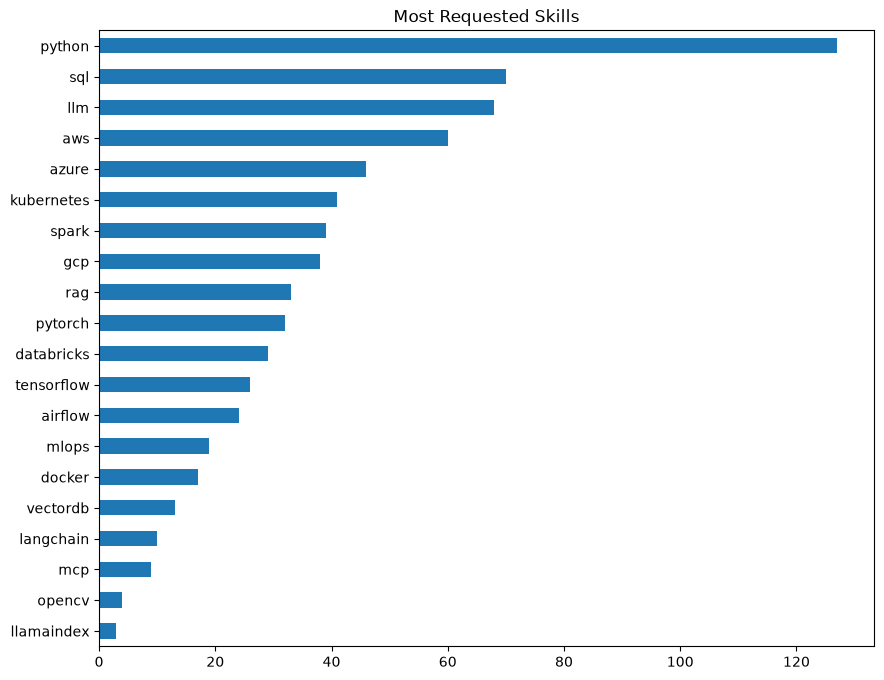

In [30]:
skill_counts.sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Most Requested Skills")

plt.savefig(
    "requested_skills.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [31]:
df_clean.groupby("real_category")[skills].mean() * 100

,python,sql,aws,azure,gcp,pytorch,tensorflow,spark,airflow,databricks,docker,kubernetes,llm,rag,langchain,llamaindex,mcp,opencv,mlops,vectordb
real_category,,,,,,,,,,,,,,,,,,,,
AI Engineer,81.250000,21.875000,37.500000,40.625000,34.375000,15.625000,18.750000,9.375000,12.500000,12.500000,21.875000,34.375000,78.125000,56.250000,21.875000,9.375,9.375000,0.000000,25.000000,25.000000
Analytics,100.000000,100.000000,37.500000,50.000000,37.500000,0.000000,0.000000,25.000000,12.500000,50.000000,0.000000,50.000000,37.500000,0.000000,0.000000,0.000,25.000000,0.000000,0.000000,0.000000
Computer Vision,100.000000,0.000000,0.000000,0.000000,0.000000,50.000000,50.000000,0.000000,0.000000,0.000000,50.000000,0.000000,50.000000,0.000000,0.000000,0.000,0.000000,50.000000,0.000000,0.000000
Data Engineer,76.666667,66.666667,43.333333,40.000000,26.666667,0.000000,0.000000,53.333333,33.333333,46.666667,10.000000,26.666667,20.000000,10.000000,0.000000,0.000,3.333333,0.000000,0.000000,6.666667
Data Scientist,95.833333,70.833333,50.000000,20.833333,12.500000,33.333333,29.166667,20.833333,4.166667,12.500000,0.000000,20.833333,45.833333,16.666667,4.166667,0.000,4.166667,0.000000,16.666667,4.166667
ML Infrastructure,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,100.000000
Machine Learning Engineer,88.235294,35.294118,47.058824,11.764706,29.411765,64.705882,70.588235,17.647059,29.411765,0.000000,23.529412,47.058824,35.294118,23.529412,11.764706,0.000,5.882353,17.647059,35.294118,5.882353
Management,100.000000,100.000000,100.000000,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000
Other,100.000000,33.333333,0.000000,33.333333,0.000000,0.000000,0.000000,33.333333,0.000000,33.333333,0.000000,0.000000,33.333333,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000


In [32]:
top_skills = (
    df_clean.groupby("real_category")[skills]
      .mean()
      .T * 100
)

top_skills

real_category,AI Engineer,Analytics,Computer Vision,Data Engineer,Data Scientist,ML Infrastructure,Machine Learning Engineer,Management,Other,Quant,Research,Software Engineer,Solutions Engineering
python,81.250,100.0,100.0,76.666667,95.833333,100.0,88.235294,100.0,100.000000,100.0,84.615385,90.909091,75.0
sql,21.875,100.0,0.0,66.666667,70.833333,100.0,35.294118,100.0,33.333333,0.0,7.692308,36.363636,100.0
aws,37.500,37.5,0.0,43.333333,50.000000,0.0,47.058824,100.0,0.000000,0.0,23.076923,72.727273,0.0
azure,40.625,50.0,0.0,40.000000,20.833333,0.0,11.764706,100.0,33.333333,0.0,0.000000,54.545455,50.0
gcp,34.375,37.5,0.0,26.666667,12.500000,0.0,29.411765,100.0,0.000000,0.0,7.692308,54.545455,0.0
pytorch,15.625,0.0,50.0,0.000000,33.333333,0.0,64.705882,0.0,0.000000,0.0,46.153846,0.000000,25.0
tensorflow,18.750,0.0,50.0,0.000000,29.166667,0.0,70.588235,0.0,0.000000,0.0,0.000000,0.000000,0.0
spark,9.375,25.0,0.0,53.333333,20.833333,0.0,17.647059,0.0,33.333333,0.0,7.692308,63.636364,25.0
airflow,12.500,12.5,0.0,33.333333,4.166667,0.0,29.411765,0.0,0.000000,0.0,7.692308,18.181818,0.0
databricks,12.500,50.0,0.0,46.666667,12.500000,0.0,0.000000,0.0,33.333333,0.0,0.000000,9.090909,50.0


In [33]:
counts = df_clean["real_category"].value_counts()

valid_categories = counts[counts >= 5].index

df_filtered = df_clean[
    df_clean["real_category"].isin(valid_categories)
]

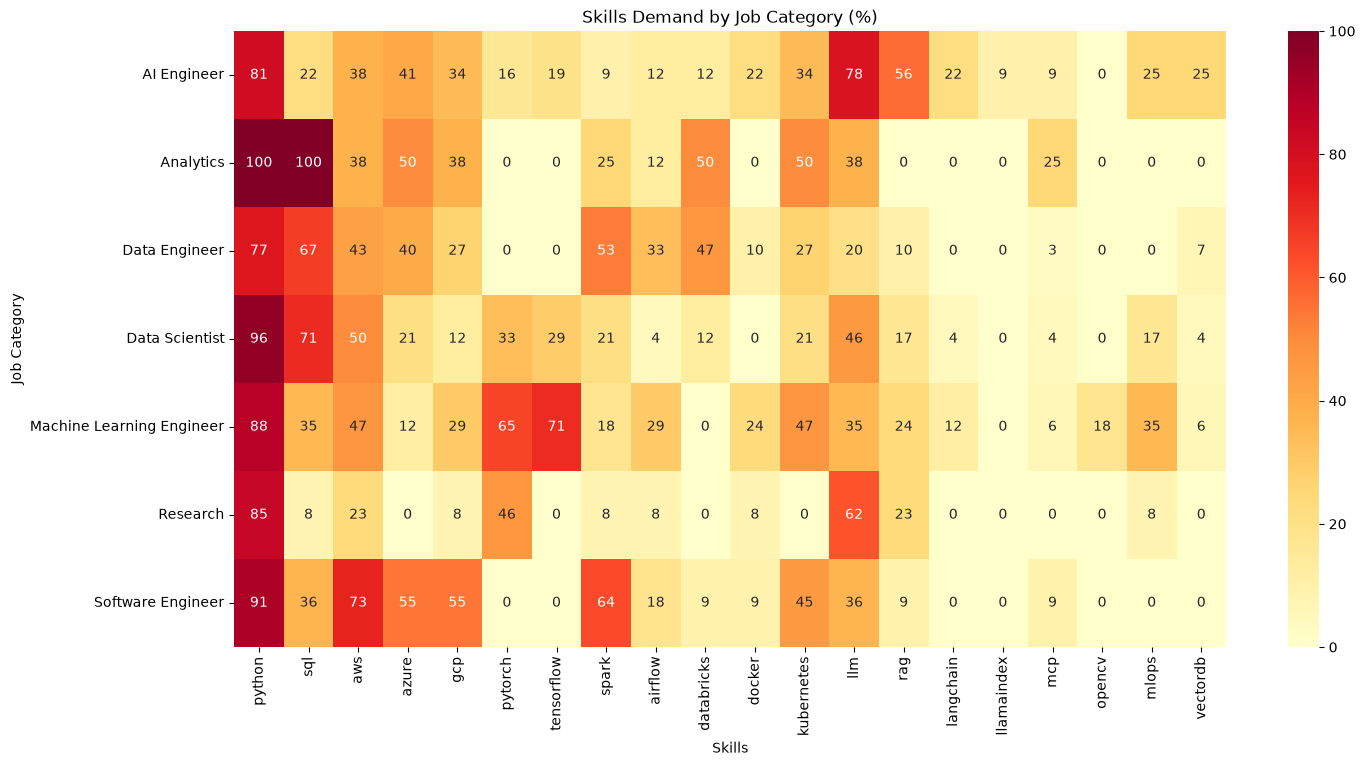

In [34]:
skill_heatmap = (
    df_filtered.groupby("real_category")[skills]
            .mean()
            * 100
)

plt.figure(figsize=(16,8))

sns.heatmap(
    skill_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.title(
    "Skills Demand by Job Category (%)"
)

plt.xlabel("Skills")
plt.ylabel("Job Category")

plt.savefig(
    "skills_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 7. Job Category Analysis

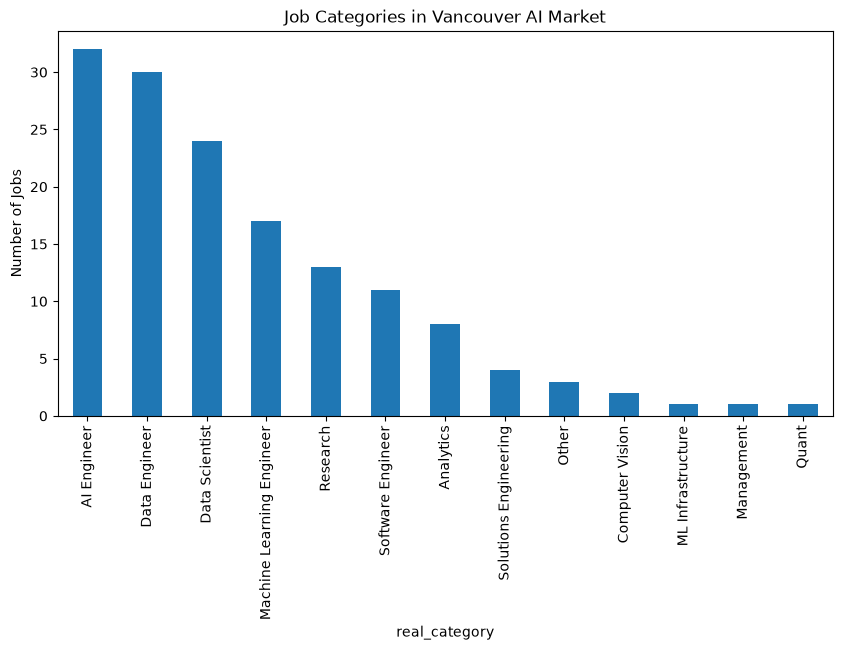

In [35]:
df_clean["real_category"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Job Categories in Vancouver AI Market")
plt.ylabel("Number of Jobs")

plt.savefig(
    "jobCategory.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [36]:
def orientation(category):

    if category == "Research":
        return "Research"

    elif category in [
        "AI Engineer",
        "Machine Learning Engineer",
        "Computer Vision"
    ]:
        return "Applied AI"

    elif category in [
        "Data Engineer",
        "Data Scientist",
        "Analytics",
        "Quant"
    ]:
        return "Data & Analytics"

    elif category in [
        "Software Engineer",
        "ML Infrastructure"
    ]:
        return "Platform Engineering"

    elif category in [
        "Solutions Engineering",
        "Management"
    ]:
        return "Solutions"

    else:
        return "Other"

In [37]:
df_clean["orientation"] = (
    df_clean["real_category"]
    .apply(orientation)
)

In [38]:
df_clean["orientation"].value_counts()

orientation
Data & Analytics        63
Applied AI              51
Research                13
Platform Engineering    12
Solutions                5
Other                    3
Name: count, dtype: int64

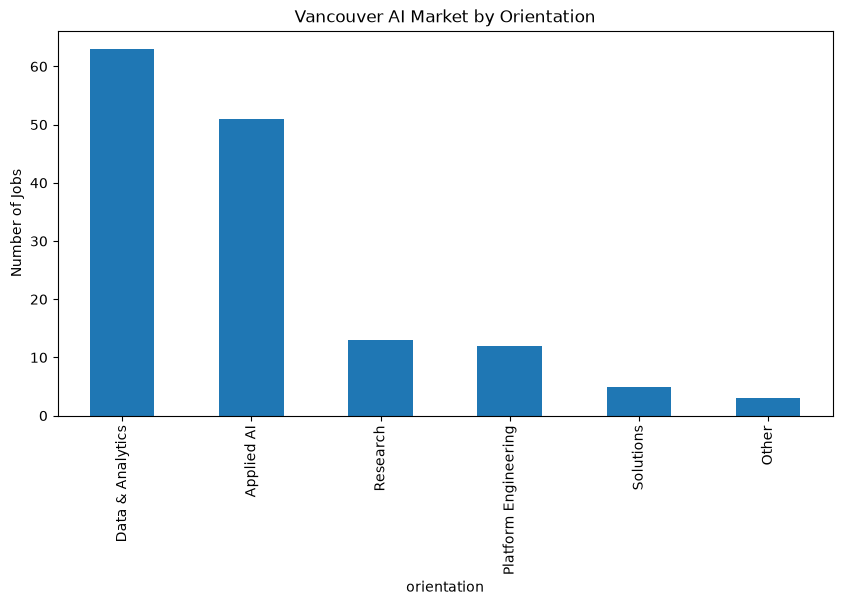

In [39]:
df_clean["orientation"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Vancouver AI Market by Orientation"
)

plt.ylabel("Number of Jobs")

plt.savefig(
    "orientation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [40]:
category_pct = (
    df_clean["real_category"]
    .value_counts(normalize=True)
    * 100
)

category_pct

real_category
AI Engineer                  21.768707
Data Engineer                20.408163
Data Scientist               16.326531
Machine Learning Engineer    11.564626
Research                      8.843537
Software Engineer             7.482993
Analytics                     5.442177
Solutions Engineering         2.721088
Other                         2.040816
Computer Vision               1.360544
ML Infrastructure             0.680272
Management                    0.680272
Quant                         0.680272
Name: proportion, dtype: float64

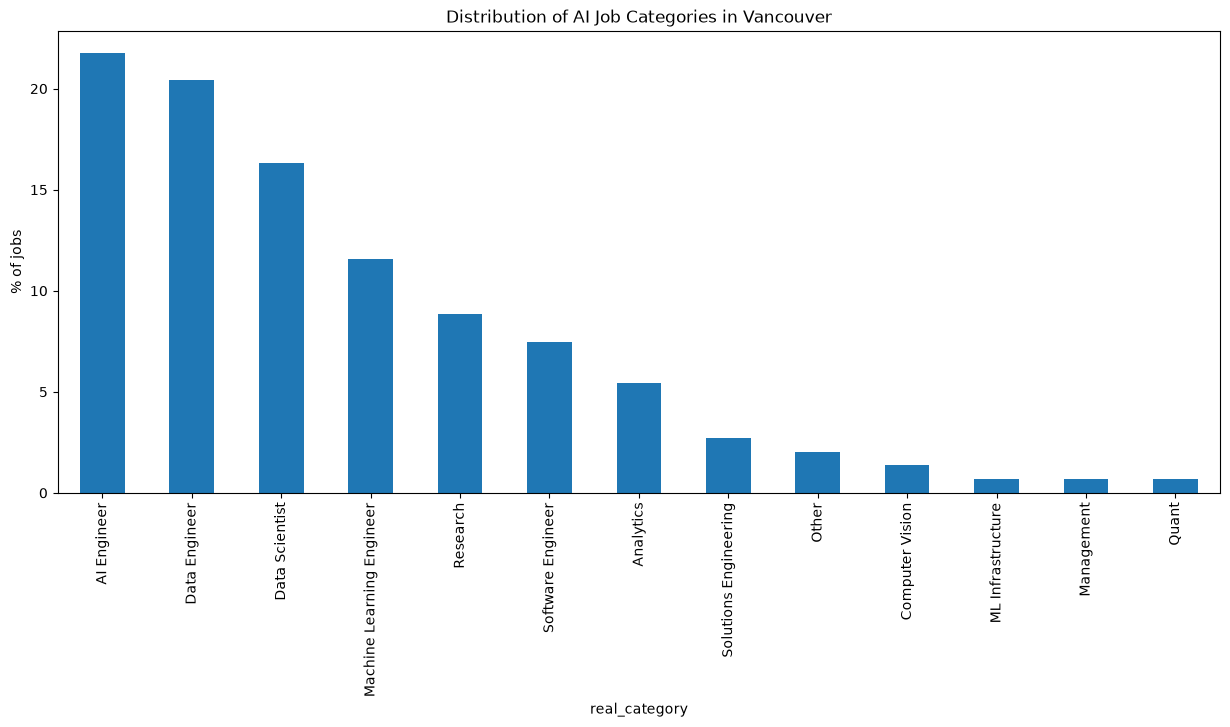

In [41]:
category_pct.plot(
    kind="bar",
    figsize=(15,6)
)

plt.ylabel("% of jobs")
plt.title("Distribution of AI Job Categories in Vancouver")
plt.xticks(rotation=90)

plt.show()

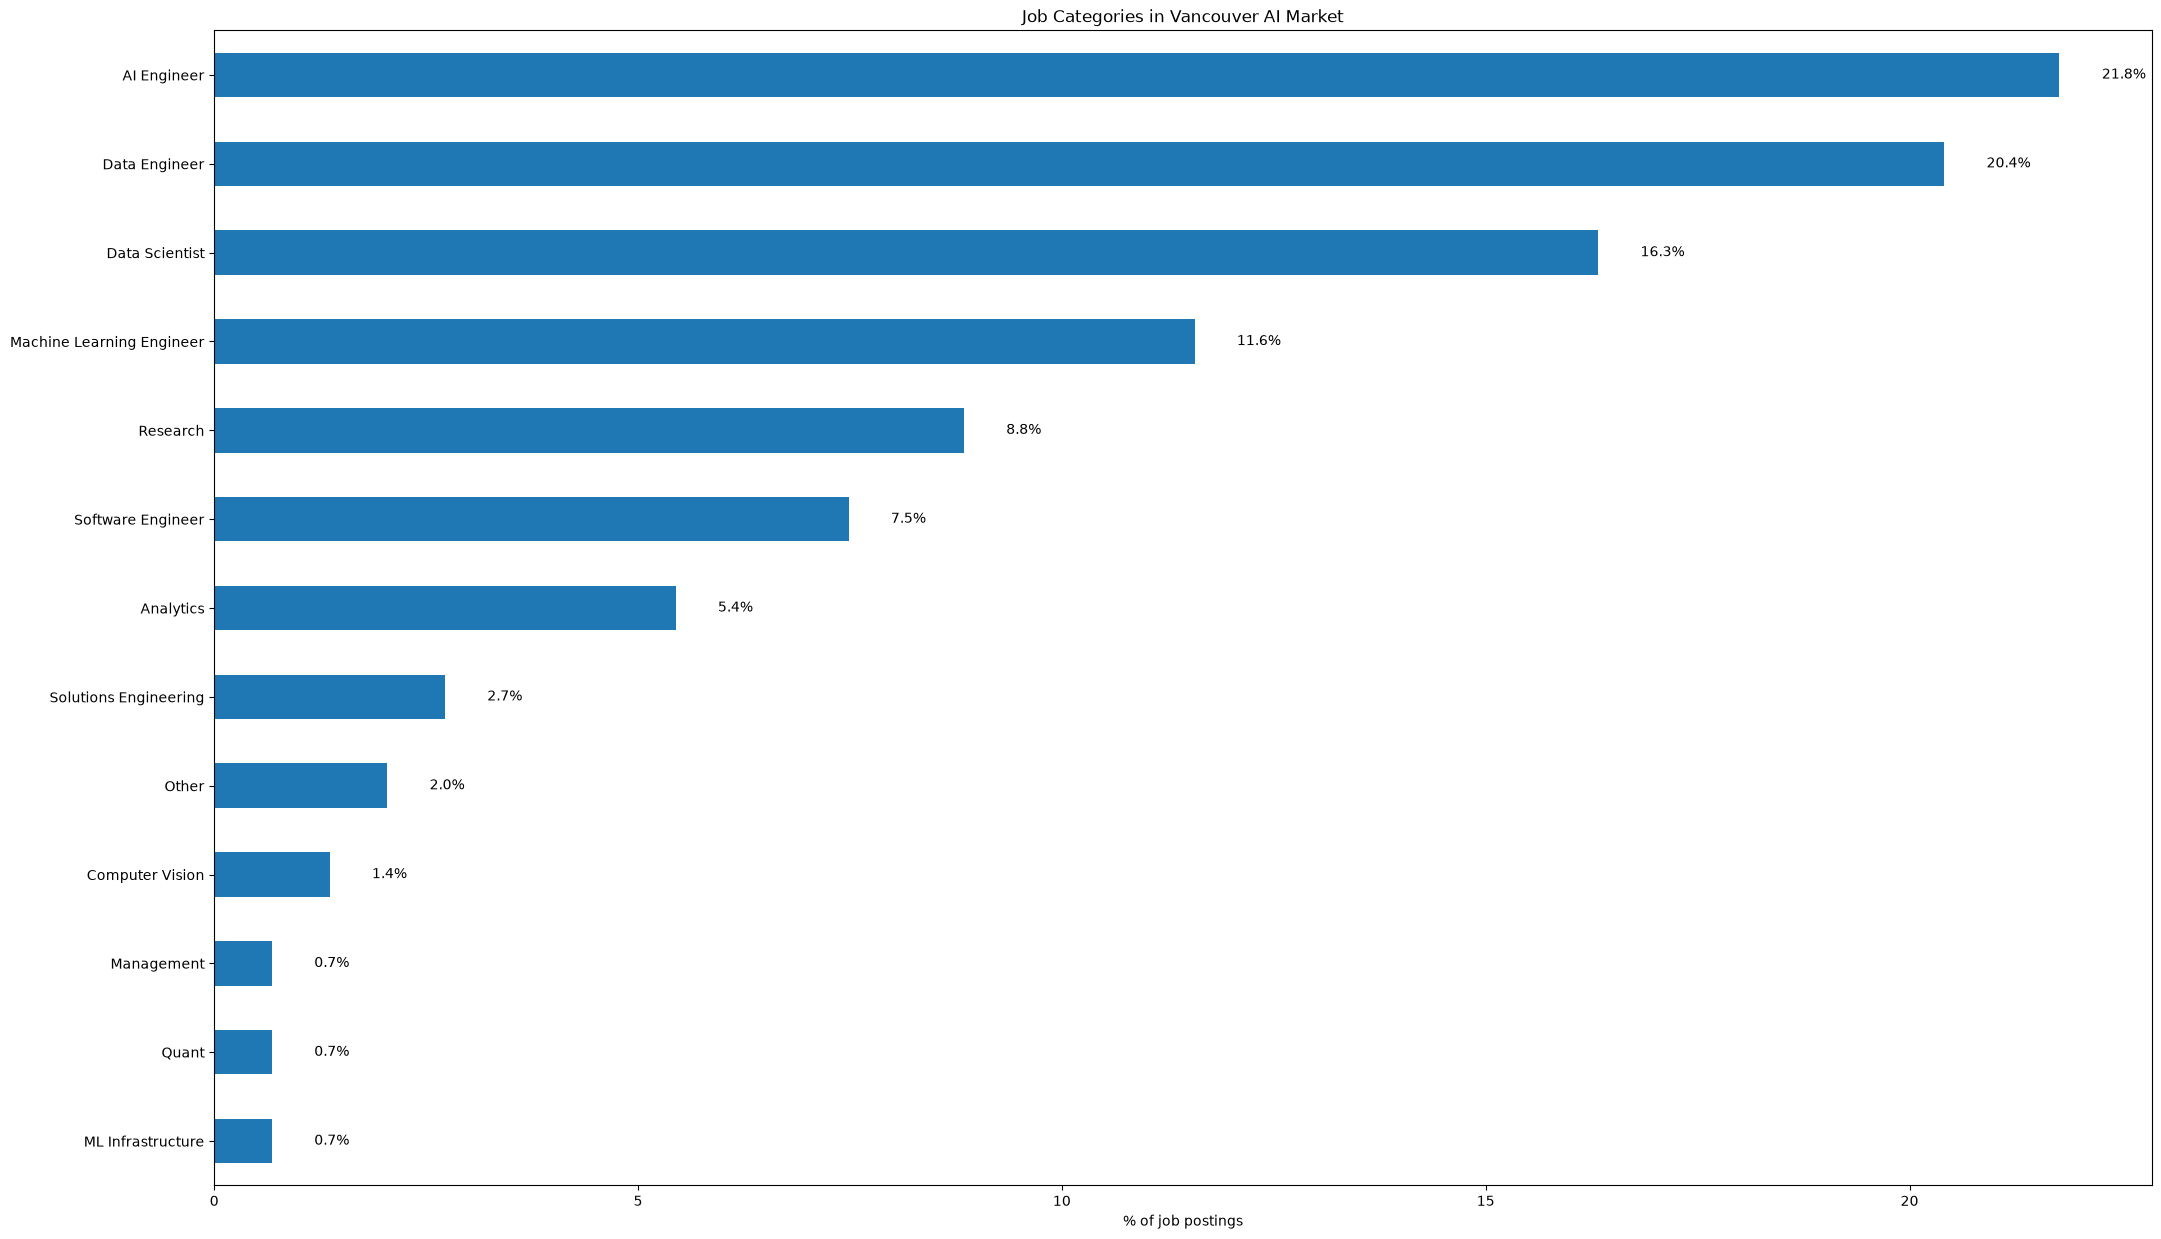

In [42]:
category_pct = (
    df_clean["real_category"]
    .value_counts(normalize=True)
    .sort_values()
    * 100
)

ax = category_pct.plot(
    kind="barh",
    figsize=(25, 15)
)

plt.title("Job Categories in Vancouver AI Market")
plt.xlabel("% of job postings")
plt.ylabel("")

for i, v in enumerate(category_pct):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")

plt.savefig(
    "skills_heatmap.png",
    dpi=600,
    bbox_inches="tight"
)    

plt.savefig(
    "distributionjobs.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [43]:
def market_type(cat):

    research = [
        "Research",
        "Computer Vision",
        "ML Infrastructure"
    ]

    if cat in research:
        return "Research"

    return "Industry"

df_clean["market_type"] = (
    df_clean["real_category"]
    .apply(market_type)
)

In [44]:
market_pct = (
    df_clean["market_type"]
    .value_counts(normalize=True)
    * 100
)

market_pct

market_type
Industry    89.115646
Research    10.884354
Name: proportion, dtype: float64

<Axes: >

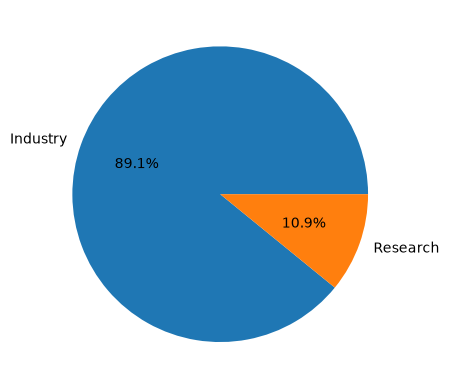

In [45]:
market_pct.plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

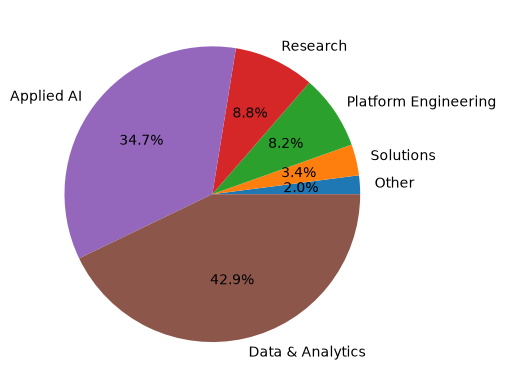

In [46]:
orientation_pct = (
    df_clean["orientation"]
    .value_counts(normalize=True)
    .sort_values()
    * 100
)

ax = orientation_pct.plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

plt.savefig(
    "repartition.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 8. Company Analysis

In [47]:
company_counts = df_clean["Company"].value_counts()

company_counts.head(20)

Company
Amazon                  5
Electronic Arts (EA)    5
SAP                     3
lululemon               3
Microsoft               3
Amazon Science          3
RBC                     3
Clio                    3
EA SPORTS               2
Apple                   2
Workday                 2
Flexday AI              2
Armstrong Collective    2
DarkVision              2
Beatdapp                2
Huawei Canada           2
Houle                   2
EviSmart™               2
Delta Controls          2
Autodesk                2
Name: count, dtype: int64

In [48]:
company_counts.value_counts()

count
1    77
2    21
3     6
5     2
Name: count, dtype: int64

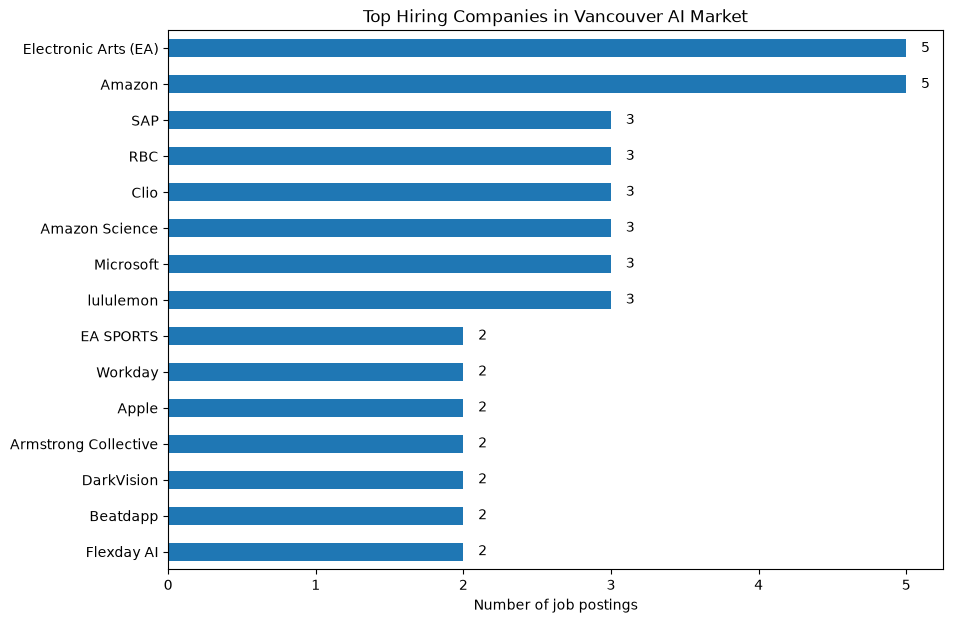

In [49]:
top_companies = company_counts.head(15).sort_values()

ax = top_companies.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top Hiring Companies in Vancouver AI Market")
plt.xlabel("Number of job postings")
plt.ylabel("")

for i, v in enumerate(top_companies):
    ax.text(v + 0.1, i, str(v), va="center")

plt.show()

In [50]:
n_companies = df_clean["Company"].nunique()
n_jobs = len(df_clean)

print(f"Unique companies: {n_companies}")
print(f"Unique jobs: {n_jobs}")
print(f"Jobs per company: {n_jobs / n_companies:.2f}")

Unique companies: 106
Unique jobs: 147
Jobs per company: 1.39


In [51]:
company_category = pd.crosstab(
    df_clean["Company"],
    df_clean["real_category"]
)

company_category.head()

real_category,AI Engineer,Analytics,Computer Vision,Data Engineer,Data Scientist,ML Infrastructure,Machine Learning Engineer,Management,Other,Quant,Research,Software Engineer,Solutions Engineering
Company,,,,,,,,,,,,,
AIM Defence,0,0,1,0,0,0,0,0,0,0,0,0,0
Activision,0,0,0,1,0,0,0,0,0,0,0,0,0
Activision Blizzard,0,0,0,1,0,0,0,0,0,0,0,0,0
Altea Healthcare,0,0,0,0,1,0,0,0,0,0,0,0,0
Amazon,0,0,0,2,2,0,0,0,0,0,1,0,0


In [52]:
top_company_names = company_counts.head(15).index

company_category_top = company_category.loc[top_company_names]

company_category_top

real_category,AI Engineer,Analytics,Computer Vision,Data Engineer,Data Scientist,ML Infrastructure,Machine Learning Engineer,Management,Other,Quant,Research,Software Engineer,Solutions Engineering
Company,,,,,,,,,,,,,
Amazon,0,0,0,2,2,0,0,0,0,0,1,0,0
Electronic Arts (EA),1,0,0,1,2,0,0,0,0,0,0,1,0
SAP,1,0,0,0,0,0,1,0,0,0,1,0,0
lululemon,1,0,0,0,0,0,0,0,0,0,2,0,0
Microsoft,0,0,0,0,1,0,0,0,0,0,0,2,0
Amazon Science,0,0,0,0,2,0,0,0,0,0,1,0,0
RBC,1,0,0,1,0,0,0,0,0,0,1,0,0
Clio,0,0,0,1,2,0,0,0,0,0,0,0,0
EA SPORTS,0,0,0,0,0,0,2,0,0,0,0,0,0


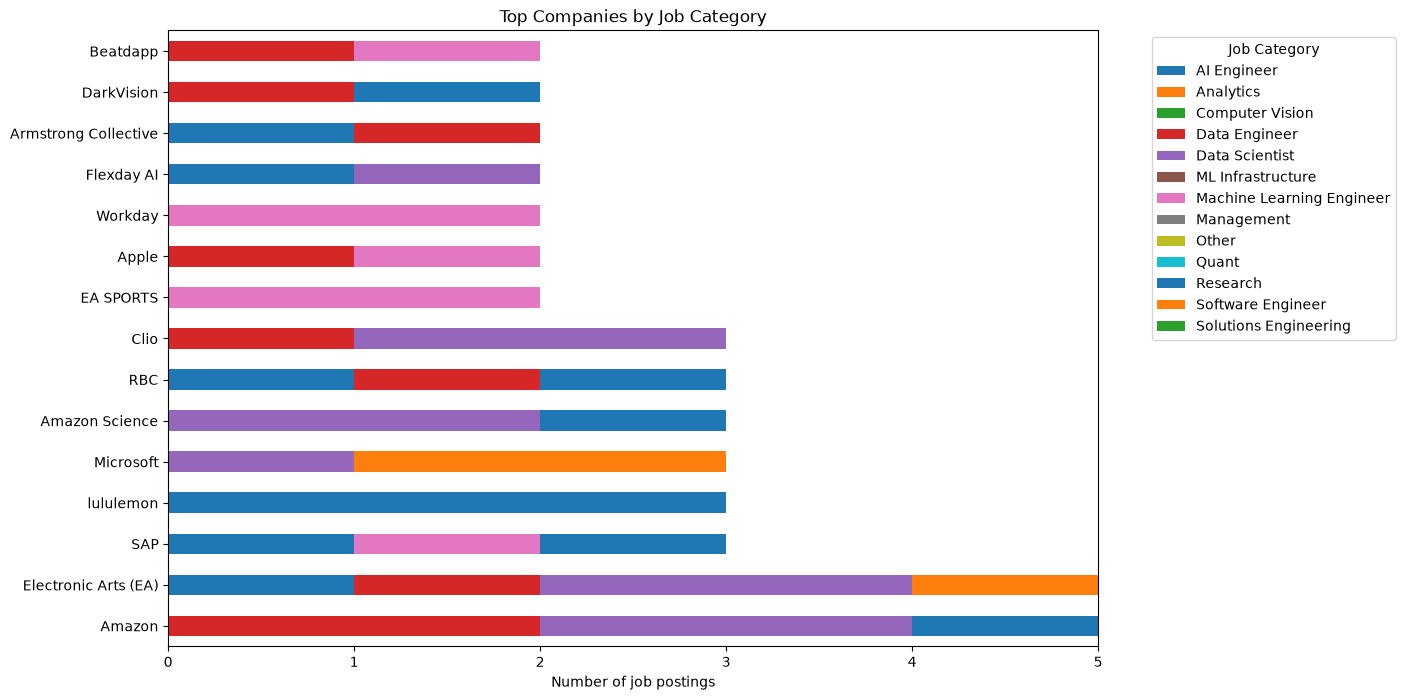

In [53]:
company_category_top.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 8)
)

plt.title("Top Companies by Job Category")
plt.xlabel("Number of job postings")
plt.ylabel("")
plt.legend(title="Job Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(
    "topperjobcategory.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [54]:
industry_counts = (
    df_clean["Industries"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

industry_counts.head(20)

Industries
Software Development                                      41
IT Services and IT Consulting                             14
Financial Services                                        13
Technology                                                 7
Information and Internet                                   7
Entertainment Providers                                    6
Research Services                                          5
and Business Consulting and Services                       4
Retail                                                     4
Construction                                               4
and IT Services and IT Consulting                          4
Hospitals and Health Care                                  4
Computer Games                                             3
Information Services                                       3
Telecommunications                                         3
Banking and Financial Services                             3
Software Deve

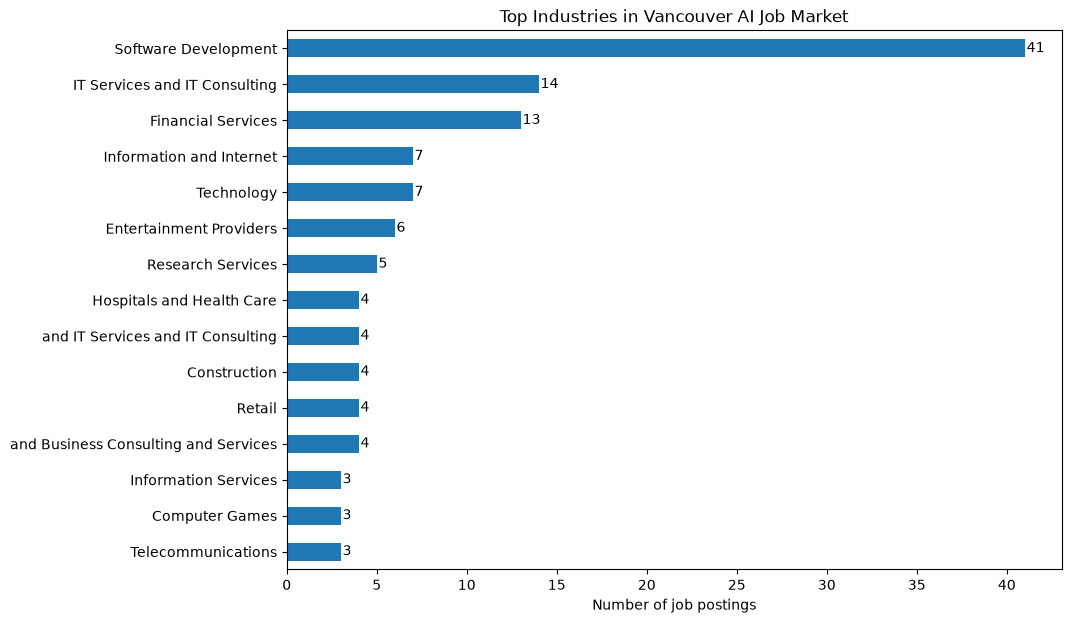

In [55]:
top_industries = industry_counts.head(15).sort_values()

ax = top_industries.plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top Industries in Vancouver AI Job Market")
plt.xlabel("Number of job postings")
plt.ylabel("")

for i, v in enumerate(top_industries):
    ax.text(v + 0.1, i, str(v), va="center")

plt.show()

In [56]:
top_10_share = company_counts.head(10).sum() / len(df_clean) * 100

print(f"Top 10 companies represent {top_10_share:.1f}% of all postings.")

Top 10 companies represent 21.8% of all postings.


## 9. Salary Analysis

In [57]:
df_clean["Description"].sample(10)

139    We are looking for a Data Scientist to join ou...
50     Location: Greater Vancouver Area (In-Office On...
53     PLEASE NOTE: COMPLETION OF OUR AI INTERVIEW BO...
87     Establish the single source of truth for custo...
72     Remarcable is purpose-built for trade contract...
94     At Coast Capital, we’re not dreaming about a b...
2      Description & Requirements\n\nElectronic Arts ...
98     A career that gives you purpose. A company tha...
40     Job Description\n\nRBC Borealis is looking for...
107    We are hiring an Analytics Architect on behalf...
Name: Description, dtype: str

In [58]:
import re

def extract_salary(text):

    if pd.isna(text):
        return np.nan

    match = re.search(
        r'\$([\d,]+)\s*-\s*\$([\d,]+)',
        text
    )

    if match:

        low = int(
            match.group(1).replace(",","")
        )

        high = int(
            match.group(2).replace(",","")
        )

        return (low + high) / 2

    return np.nan

df_clean["salary_avg"] = (
    df_clean["Description"]
    .apply(extract_salary)
)

In [59]:
df_clean["salary_avg"] = (
    df_clean["Description"]
    .apply(extract_salary)
)

In [60]:
df_clean["salary_avg"].notna().sum()

np.int64(36)

In [61]:
salary_df = df_clean.dropna(
    subset=["salary_avg"]
)

In [62]:
salary_by_category = (
    salary_df
    .groupby("real_category")["salary_avg"]
    .mean()
    .sort_values()
)

salary_by_category

real_category
Analytics                    110000.000000
Other                        121250.000000
Management                   129500.000000
AI Engineer                  130078.125000
Data Engineer                130296.875000
Data Scientist               153760.000000
Software Engineer            159825.000000
Machine Learning Engineer    171425.500000
Research                     181098.333333
Name: salary_avg, dtype: float64

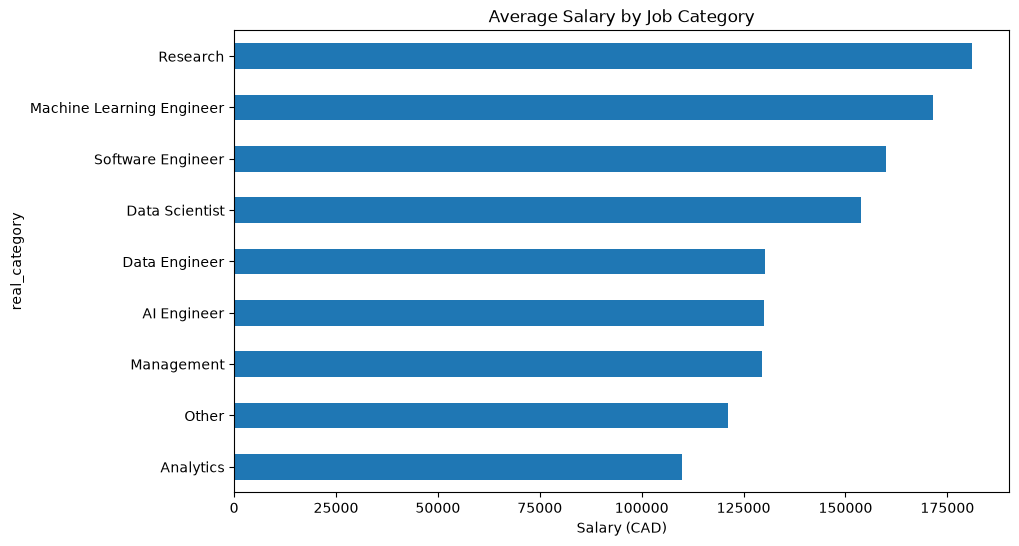

In [63]:
ax = salary_by_category.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title(
    "Average Salary by Job Category"
)

plt.xlabel("Salary (CAD)")

plt.savefig(
    "salary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [67]:
salary_by_orientation = (
    salary_df
    .groupby("orientation")["salary_avg"]
    .median()
    .sort_values()
)

salary_by_orientation

orientation
Other                   121250.0
Solutions               129500.0
Data & Analytics        135000.0
Applied AI              143950.0
Platform Engineering    159825.0
Research                169775.0
Name: salary_avg, dtype: float64

In [68]:
summary = pd.DataFrame({
    "Median Salary": (
        salary_df
        .groupby("orientation")["salary_avg"]
        .median()
    ),
    "Jobs with Salary": (
        salary_df
        .groupby("orientation")
        .size()
    )
})

summary

,Median Salary,Jobs with Salary
orientation,,
Applied AI,143950.0,13
Data & Analytics,135000.0,15
Other,121250.0,2
Platform Engineering,159825.0,2
Research,169775.0,3
Solutions,129500.0,1


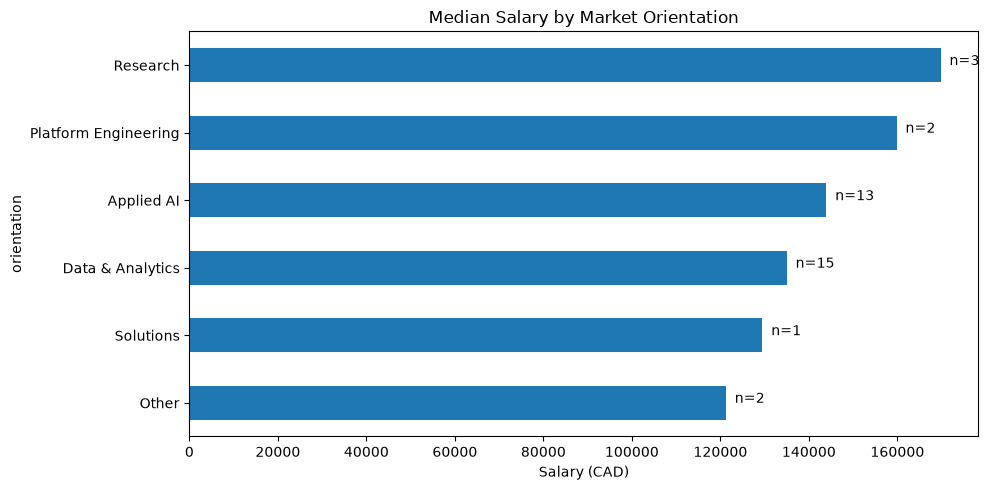

In [65]:
salary_by_orientation = (
    salary_df
    .groupby("orientation")["salary_avg"]
    .median()
    .sort_values()
)

counts = (
    salary_df
    .groupby("orientation")
    .size()
)

ax = salary_by_orientation.plot(
    kind="barh",
    figsize=(10,5)
)

for i, (orientation, salary) in enumerate(
    salary_by_orientation.items()
):
    ax.text(
        salary + 2000,
        i,
        f'n={counts[orientation]}'
    )

plt.title(
    "Median Salary by Market Orientation"
)

plt.xlabel(
    "Salary (CAD)"
)

plt.tight_layout()

plt.savefig(
    "mediansalary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

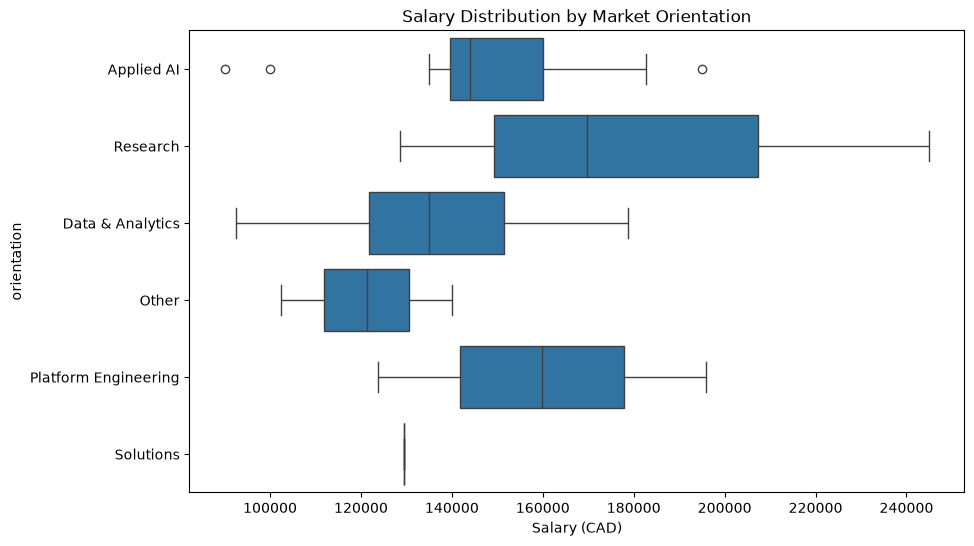

In [66]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=salary_df,
    x="salary_avg",
    y="orientation"
)

plt.title(
    "Salary Distribution by Market Orientation"
)

plt.xlabel(
    "Salary (CAD)"
)

plt.savefig(
    "boxplotmediansalary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

## 10. Conclusions

This analysis of 147 unique AI-related job postings in Vancouver shows that the local AI market is primarily driven by industry needs rather than academic research. After cleaning duplicate postings, approximately 89% of opportunities were industry-oriented, while only about 11% were research-focused.

The largest segments of the market were AI Engineering, Data Engineering and Data Science, indicating that companies are currently prioritizing the deployment, integration and operationalization of AI systems over fundamental research.

Across nearly all categories, Python remains the dominant skill, while SQL, cloud technologies and machine learning frameworks such as PyTorch and TensorFlow continue to be highly valued. Recent AI-specific technologies including LLMs, RAG systems, vector databases and MLOps tools are increasingly appearing in job descriptions, particularly for Applied AI roles.

Salary analysis suggests that research-oriented and machine learning engineering positions tend to command the highest compensation, although the salary sample was limited to postings that explicitly disclosed compensation information. Only 36 postings contained usable salary data, so these results should be interpreted cautiously.

Overall, the Vancouver AI ecosystem appears mature and strongly industry-driven. The majority of opportunities are focused on applying and scaling AI solutions rather than developing new algorithms. For professionals seeking to enter the market, the combination of Python, machine learning, cloud platforms and modern generative AI technologies appears to provide the strongest alignment with current employer demand.